In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [62]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [63]:
df = pd.read_csv("../data/diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [65]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [66]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/Users/mohanasritha/Desktop/Disease_detection/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [68]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6538 - loss: 0.6776 - val_accuracy: 0.6423 - val_loss: 0.6723
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6538 - loss: 0.6563 - val_accuracy: 0.6423 - val_loss: 0.6655
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6538 - loss: 0.6472 - val_accuracy: 0.6423 - val_loss: 0.6557
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6538 - loss: 0.6390 - val_accuracy: 0.6423 - val_loss: 0.6440
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6599 - loss: 0.6282 - val_accuracy: 0.6423 - val_loss: 0.6278
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6741 - loss: 0.6170 - val_accuracy: 0.6341 - val_loss: 0.6157
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6782 - loss: 0.6059 - val_accuracy: 0.6341 - val_loss: 0.6054
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6843 - loss: 0.5965 - val_accuracy: 0.6667 - val_loss:

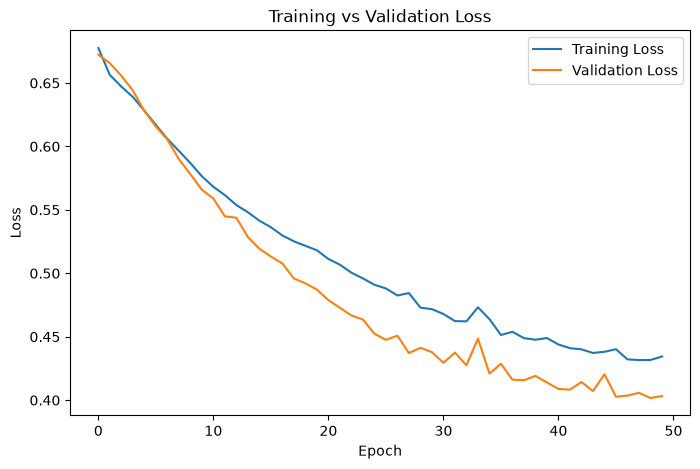

In [69]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [70]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score

# Predictions
y_prob = model.predict(X_test)

# Convert probabilities to 0/1
y_pred = (y_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("AUC-ROC:", auc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
Accuracy: 0.7272727272727273
Precision: 0.6111111111111112
Recall: 0.6111111111111112
F1: 0.6111111111111112
AUC-ROC: 0.8355555555555556


In [71]:
import pandas as pd

mlp_result = pd.DataFrame({
    "model": ["MLP"],
    "accuracy": [accuracy],
    "precision": [precision],
    "recall": [recall],
    "f1": [f1],
    "auc_roc": [auc]
})

mlp_result

,model,accuracy,precision,recall,f1,auc_roc
0,MLP,0.727273,0.611111,0.611111,0.611111,0.835556


In [72]:
mlp_result.to_csv(
    "../results/results_log.csv",
    mode="a",
    header=False,
    index=False
)

print("MLP results saved!")

MLP results saved!


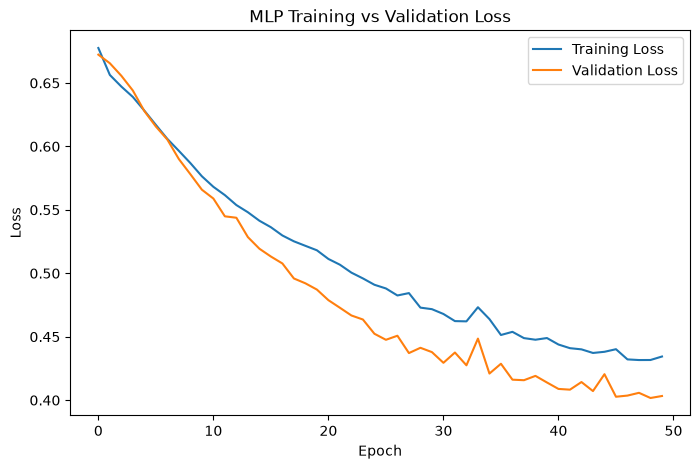

In [73]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training vs Validation Loss")
plt.legend()

plt.savefig("../results/mlp_loss_curve.png")

plt.show()

In [74]:
# MLP Hyperparameter Tuning

In [75]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau

import numpy as np
import pandas as pd
import json

In [76]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-6
)

In [77]:
def build_model():

    model = Sequential([
        Dense(64, activation='relu',
              input_shape=(X_train.shape[1],)),

        Dropout(0.3),

        Dense(32, activation='relu'),

        Dropout(0.3),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [78]:
model_32 = build_model()

history_32 = model_32.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[reduce_lr],
    verbose=1
)

Epoch 1/50


/Users/mohanasritha/Desktop/Disease_detection/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6456 - loss: 0.6641 - val_accuracy: 0.6423 - val_loss: 0.6721 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6558 - loss: 0.6615 - val_accuracy: 0.6423 - val_loss: 0.6679 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6456 - loss: 0.6593 - val_accuracy: 0.6423 - val_loss: 0.6637 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6517 - loss: 0.6426 - val_accuracy: 0.6423 - val_loss: 0.6555 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6497 - loss: 0.6412 - val_accuracy: 0.6423 - val_loss: 0.6486 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6578 - loss: 0.6365 - val_accuracy: 0.6423 - val_loss: 0.6430 - learning_rate: 0.0010
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6721 - loss: 0.6302 - val_accuracy: 0.6341 - va

In [79]:
model_64 = build_model()

history_64 = model_64.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[reduce_lr],
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6049 - loss: 0.6834 - val_accuracy: 0.6423 - val_loss: 0.6719 - learning_rate: 0.0010
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6578 - loss: 0.6685 - val_accuracy: 0.6423 - val_loss: 0.6655 - learning_rate: 0.0010
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6477 - loss: 0.6618 - val_accuracy: 0.6423 - val_loss: 0.6616 - learning_rate: 0.0010
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6578 - loss: 0.6604 - val_accuracy: 0.6423 - val_loss: 0.6571 - learning_rate: 0.0010
Epoch 5/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6562 - loss: 0.6531
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6599 - loss: 0.6533 - val_accuracy: 0.6423 - val_loss: 0.6531 - learning_rate: 0.0010
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6558 - loss: 0.6527 - val_accuracy: 0.6423 - val_l

In [80]:
model_128 = build_model()

history_128 = model_128.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[reduce_lr],
    verbose=1
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.4786 - loss: 0.6963 - val_accuracy: 0.6504 - val_loss: 0.6897 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6090 - loss: 0.6808 - val_accuracy: 0.6341 - val_loss: 0.6817 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6293 - loss: 0.6773 - val_accuracy: 0.6341 - val_loss: 0.6761 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6578 - loss: 0.6655 - val_accuracy: 0.6423 - val_loss: 0.6724 - learning_rate: 0.0010
Epoch 5/50
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6250 - loss: 0.6679
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6619 - loss: 0.6639 - val_accuracy: 0.6423 - val_loss: 0.6701 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6578 - loss: 0.6636 - val_accuracy: 0.6423 - val_l

In [81]:
best_32 = max(history_32.history['val_accuracy'])

best_64 = max(history_64.history['val_accuracy'])

best_128 = max(history_128.history['val_accuracy'])

print("Batch 32 :", best_32)
print("Batch 64 :", best_64)
print("Batch 128:", best_128)

Batch 32 : 0.8211382031440735
Batch 64 : 0.6504064798355103
Batch 128: 0.6504064798355103


In [82]:
results = {
    32: best_32,
    64: best_64,
    128: best_128
}

best_batch = max(results, key=results.get)

print("Best Batch Size:", best_batch)

Best Batch Size: 32


In [83]:
best_config = {
    "model": "MLP",
    "hidden_layers": [64, 32],
    "dropout": 0.3,
    "optimizer": "Adam",
    "epochs": 50,
    "batch_size": int(best_batch),
    "best_validation_accuracy": float(results[best_batch])
}

In [84]:
with open("../results/best_config.json", "w") as f:
    json.dump(best_config, f, indent=4)

print("best_config.json saved")

best_config.json saved


In [85]:
with open("../results/best_config.json") as f:
    print(f.read())

{
    "model": "MLP",
    "hidden_layers": [
        64,
        32
    ],
    "dropout": 0.3,
    "optimizer": "Adam",
    "epochs": 50,
    "batch_size": 32,
    "best_validation_accuracy": 0.8211382031440735
}
